<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica28_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Mario Amador - 267370.

### Instrucciones

La presente tarea tiene como objetivo aplicar técnicas de aprendizaje automático para el tratamiento de clases no balanceadas utilizando un problema de clasificación real.

Para el desarrollo de la actividad deberán utilizar el conjunto de datos:

**compustat.csv**

Consideraciones importantes:

* El conjunto de datos contiene 21 atributos.

* El primer atributo corresponde a un índice, por lo que deberá ser ignorado durante el análisis y entrenamiento.

* El último atributo corresponde a la etiqueta de clase.

* Los atributos restantes deberán utilizarse como variables predictoras.

La solución deberá desarrollarse en un cuaderno de Google Colab o Jupyter Notebook almacenado en GitHub. La entrega consistirá en compartir la liga pública del notebook para su revisión.

La tarea deberá contener las siguientes secciones:

# 1. Análisis Exploratorio de Datos (AED)

Para esta actividad revisa el Notebook que está en Teams en la Sesión 27 y que se llama DataLeakage_ClassImbalance.ipynb

Realizar:

* Un diagrama de barras mostrando la distribución de las clases.

* Diagramas de densidad KDE para los atributos 5 y 13.

* Un análisis breve sobre el nivel de desbalance presente en el conjunto de datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/Unidad03/compustat.csv')
df.head(5)

,idx,at0,at1,at2,at3,at4,at5,at6,at7,at8,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


In [4]:
df = df.iloc[:, 1:]

print(f"Dimensiones del dataset: {df.shape}")
df.head(5)

Dimensiones del dataset: (13657, 21)


,at0,at1,at2,at3,at4,at5,at6,at7,at8,at9,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,0.633688,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,0.697423,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,0.628921,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,0.643100,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,0.652961,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


/tmp/ipykernel_20956/3073750097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette='viridis')


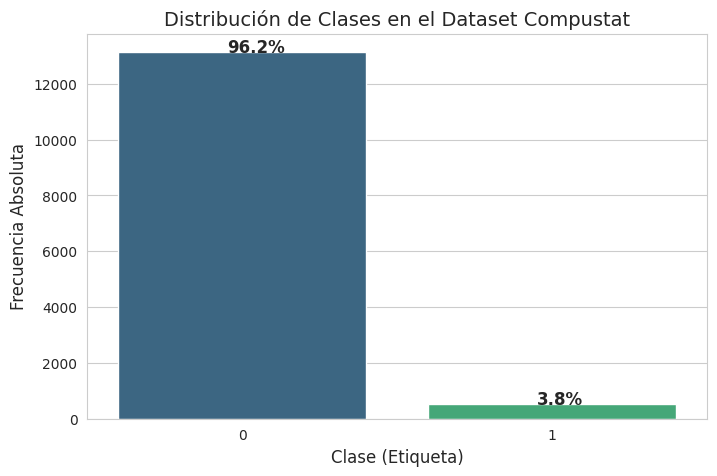

In [5]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Conteo de clases (última columna)
target_col = df.columns[-1]
ax = sns.countplot(x=target_col, data=df, palette='viridis')

# porcentaje
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 0.5
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.title('Distribución de Clases en el Dataset Compustat', fontsize=14)
plt.xlabel('Clase (Etiqueta)', fontsize=12)
plt.ylabel('Frecuencia Absoluta', fontsize=12)
plt.show()

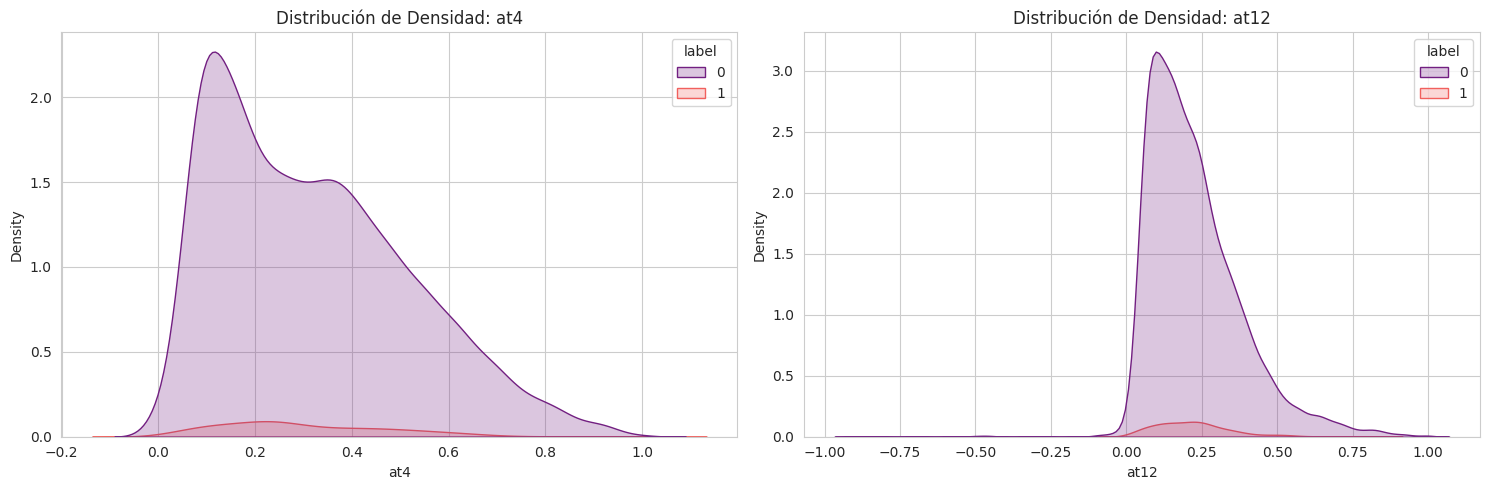

In [6]:
# Identificamos los nombres de los atributos 5 y 13
attr_5 = df.columns[4]
attr_13 = df.columns[12]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico para Atributo 5
sns.kdeplot(data=df, x=attr_5, hue=target_col, fill=True, ax=axes[0], palette='magma')
axes[0].set_title(f'Distribución de Densidad: {attr_5}', fontsize=12)

# Gráfico para Atributo 13
sns.kdeplot(data=df, x=attr_13, hue=target_col, fill=True, ax=axes[1], palette='magma')
axes[1].set_title(f'Distribución de Densidad: {attr_13}', fontsize=12)

plt.tight_layout()
plt.show()

### En este apartado mostramos el diagrama de densidad para todas las barras

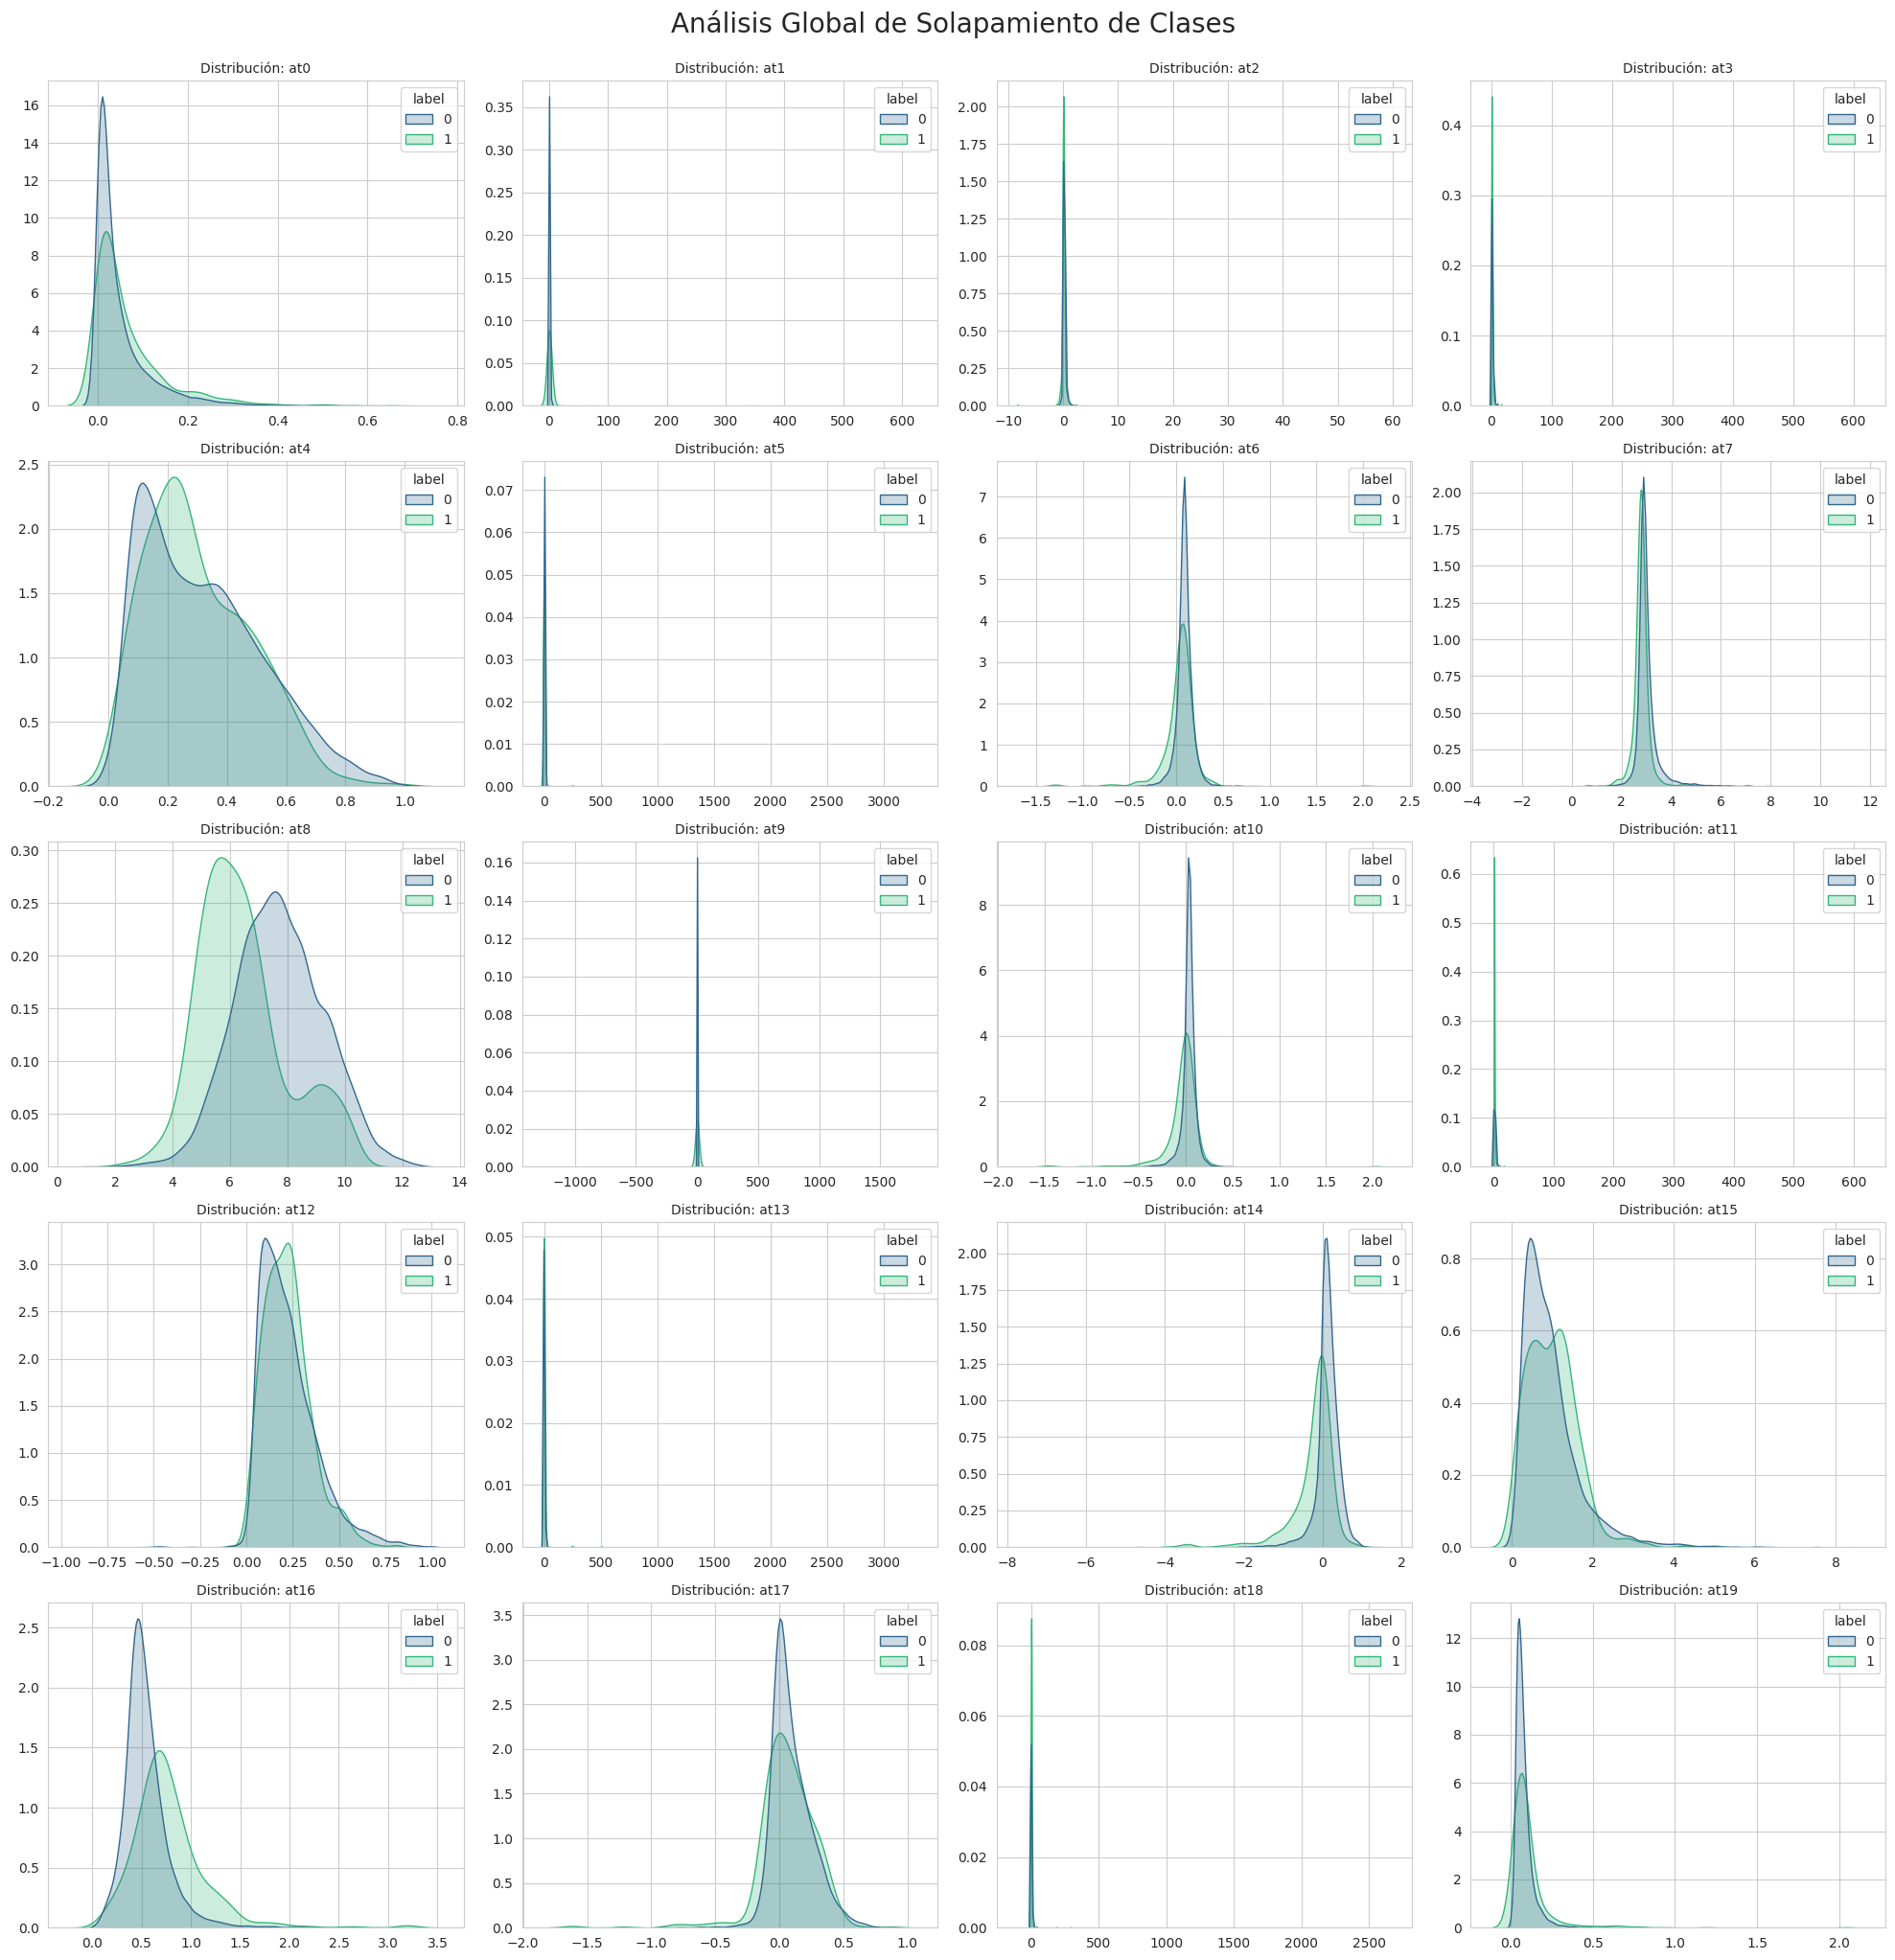

In [7]:
# Definimos las variables predictoras (todas menos la etiqueta de clase)
features = df.columns[:-1]
target = df.columns[-1]

# Calculamos el número de filas y columnas para la cuadrícula (grid)
# Por ejemplo, para 20 atributos, una cuadrícula de 5x4
n_features = len(features)
n_cols = 4
n_rows = (n_features // n_cols) + (n_features % n_cols > 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(features):
    sns.kdeplot(data=df, x=col, hue=target, fill=True, ax=axes[i], palette='viridis', common_norm=False)
    axes[i].set_title(f'Distribución: {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Eliminamos ejes vacíos si el número de variables no es múltiplo de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Análisis Global de Solapamiento de Clases', fontsize=20, y=1.02)
plt.show()

## Análisis breve del nivel de desbalance

El conjunto de datos presenta un desbalance severo entre las clases. A partir de la gráfica de distribución de clases, se observa que la clase mayoritaria (0) representa aproximadamente el 96.2% de las observaciones, mientras que la clase minoritaria (1) únicamente corresponde al 3.8% del total.

Este nivel de desbalance implica que un modelo de clasificación entrenado directamente sobre los datos originales tenderá a favorecer la clase mayoritaria, ya que puede obtener una alta exactitud (accuracy) simplemente prediciendo la mayoría de los casos como clase 0. Por esta razón, métricas como accuracy pueden resultar engañosas en este problema.

Además, los diagramas de densidad KDE muestran un importante solapamiento entre clases en varios atributos. En particular, para los atributos at5 y at13, ambas clases comparten regiones similares de distribución, aunque la clase minoritaria presenta menor densidad debido a la baja cantidad de muestras disponibles. Esto sugiere que la separación entre clases no es trivial y que el modelo podría tener dificultades para identificar correctamente los ejemplos de la clase minoritaria.

El análisis global de densidades también evidencia que algunos atributos presentan mayor capacidad discriminativa que otros. Sin embargo, el fuerte desbalance puede provocar que el modelo aprenda patrones dominados por la clase mayoritaria y reduzca su capacidad de detección sobre la clase minoritaria.

Por estas razones, resulta necesario aplicar técnicas de tratamiento de clases no balanceadas, como SMOTEENN y One-Sided Selection, con el objetivo de mejorar la representación de la clase minoritaria y lograr un modelo más robusto y equilibrado.

# Modelo Base

Entrenar un modelo baseline utilizando:

```
Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])
```

Este modelo deberá entrenarse sin aplicar métodos de tratamiento de desbalance y servirá como referencia para comparar los resultados posteriores.

## 2. Entrenamiento y Evaluación del Modelo Base (Baseline)

### Justificación Teórica y Arquitectura del Modelo
Antes de aplicar técnicas de tratamiento de desbalance, es imperativo establecer un **modelo de referencia (baseline)**. Para esto, utilizaremos una Máquina de Vectores de Soporte (SVM) con un Kernel de Función de Base Radial (RBF).

Dado que el SVM es sensible a la escala de las características (ya que basa su optimización en distancias), el escalado de los datos es obligatorio. Para garantizar el rigor metodológico y **prevenir el Data Leakage (Fuga de Datos)**, encapsularemos el preprocesamiento y el estimador dentro de un objeto `Pipeline` de Scikit-Learn.

* **¿Por qué un Pipeline?** Si aplicáramos `StandardScaler` a todo el conjunto de datos antes de la validación cruzada, la media y varianza del conjunto de prueba "filtrarían" información al conjunto de entrenamiento. El `Pipeline` asegura que el escalado se ajuste (`fit`) **solo** con los datos de entrenamiento de cada pliegue de la validación cruzada.
* **Validación Cruzada Estratificada:** Utilizaremos `StratifiedKFold` con 5 particiones para garantizar que la proporción de la clase minoritaria se mantenga constante en cada iteración de entrenamiento y prueba.

Entrenando el modelo base con Validación Cruzada (5 folds)...

--- Reporte de Clasificación (Modelo Base) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13137
           1       1.00      0.01      0.02       520

    accuracy                           0.96     13657
   macro avg       0.98      0.50      0.50     13657
weighted avg       0.96      0.96      0.94     13657



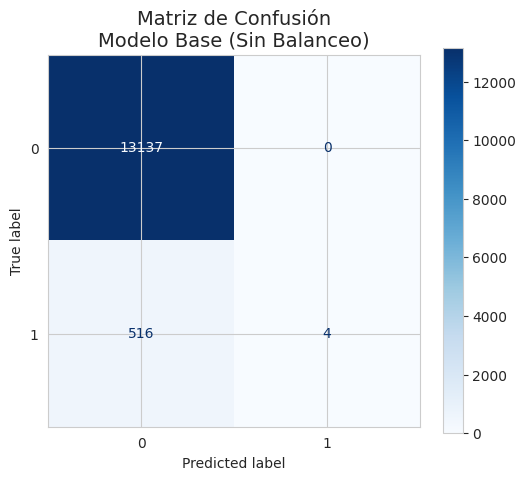

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparación de los datos
# Aseguramos ignorar la primera columna (índice) y separamos la variable objetivo
X = df.iloc[:, 1:-1]  # Variables predictoras
y = df.iloc[:, -1]    # Etiqueta de clase

# 2. Definición del Pipeline del Modelo Base
# Se integra el escalado estandarizado y el clasificador SVM
pipeline_base = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 3. Configuración de la Validación Cruzada
# StratifiedKFold preserva el porcentaje de muestras de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Entrenamiento y Predicción (Cross-Validation)
# cross_val_predict nos devuelve las predicciones "limpias" para cada instancia
# cuando esta fue parte del conjunto de prueba (fold de validación)
print("Entrenando el modelo base con Validación Cruzada (5 folds)...")
y_pred_base = cross_val_predict(pipeline_base, X, y, cv=skf)

# 5. Evaluación de Resultados Multimétrica
print("\n--- Reporte de Clasificación (Modelo Base) ---")
# El classification_report incluye Accuracy, Precision, Recall y F1-Score
print(classification_report(y, y_pred_base))

# 6. Visualización de la Matriz de Confusión
cm_base = confusion_matrix(y, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=np.unique(y))

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión\nModelo Base (Sin Balanceo)', fontsize=14)
plt.show()

### Análisis Crítico de los Resultados del Modelo Base

Al evaluar el desempeño del modelo SVM (Baseline) sin tratamiento de desbalance, los resultados del reporte de clasificación confirman empíricamente las limitaciones teóricas de los modelos tradicionales ante clases severamente desbalanceadas:

1.  **La Paradoja de la Exactitud (Accuracy Paradox):**
    El modelo alcanza un **Accuracy global del 96%**. En un contexto ingenuo, esto podría interpretarse como un modelo excelente. Sin embargo, al observar el soporte (13,137 instancias para la clase 0 vs. solo 520 para la clase 1), es evidente que este alto puntaje es un espejismo estadístico. El clasificador ha adoptado una postura "perezosa", sesgando su hiperplano de decisión para predecir abrumadoramente la clase mayoritaria.

2.  **Colapso de la Exhaustividad (Recall) en la Clase Minoritaria:**
    La métrica más crítica en este escenario es el **Recall de la clase 1, el cual es de apenas 0.01 (1%)**. Esto significa que de todos los casos positivos reales en nuestro conjunto de datos, el modelo base ignoró el 99% de ellos, clasificándolos erróneamente como negativos (Falsos Negativos). En un problema real de analítica predictiva (como detección de fraudes o diagnósticos médicos), este comportamiento invalida por completo la utilidad del modelo.

3.  **F1-Score como Métrica de la Verdad:**
    Dado que el F1-Score es la media armónica entre Precision y Recall, su valor penaliza fuertemente los desequilibrios extremos entre ambas métricas. El **F1-Score de 0.02** para la clase minoritaria expone la incapacidad real del modelo SVM (con hiperparámetros por defecto y datos originales) para capturar la frontera de decisión de la clase minoritaria debido al solapamiento y la falta de densidad de datos.

> **Conclusión Técnica:** Este diagnóstico inicial justifica absolutamente la necesidad de intervenir el conjunto de datos de entrenamiento. Queda demostrado que la optimización del SVM se ha visto dominada por la clase mayoritaria. Para obligar al modelo a aprender los patrones de la clase minoritaria, es imperativo aplicar técnicas de remuestreo.

# 3. Tratamiento de Clases No Balanceadas

Aplicar y comparar los siguientes métodos:

* SMOTEENN

* One-Sided Selection

Para cada método:

* Mostrar la nueva distribución de clases después del balanceo.

* Entrenar nuevamente el modelo SVM utilizando los datos balanceados.



## 3. Tratamiento de Clases No Balanceadas: Enfoques Híbridos y Submuestreo Inteligente

Tras comprobar el colapso del Recall en el modelo base, implementaremos dos arquitecturas de remuestreo a nivel de datos. Es vital entender las diferencias en su complejidad algorítmica y su impacto en el solapamiento geométrico de las clases:

### 3.1. SMOTEENN (Algoritmo Híbrido)
SMOTEENN combina sobremuestreo y submuestreo secuencial:
1.  **SMOTE (Synthetic Minority Over-sampling Technique):** Crea instancias sintéticas interpolando puntos entre los $k$-vecinos más cercanos de la clase minoritaria.
2.  **ENN (Edited Nearest Neighbors):** Actúa como un filtro de limpieza. Si una instancia (sintética o real) tiene una clase distinta a la mayoría de sus vecinos cercanos, es eliminada.
* **Justificación Teórica:** Nuestro KDE previo mostró un alto solapamiento. SMOTE por sí solo crearía datos ruidosos dentro del territorio de la clase mayoritaria. ENN limpia esas fronteras de decisión, facilitando el trabajo del kernel RBF del SVM.
* **Complejidad:** Alta $\mathcal{O}(N^2 \cdot d)$, debido al cálculo repetitivo de distancias inter-vecinos.

### 3.2. One-Sided Selection (Submuestreo Inteligente)
A diferencia del submuestreo aleatorio que pierde información valiosa, OSS retiene casos representativos y elimina redundancias de la clase mayoritaria:
1.  Utiliza **Tomek Links** para eliminar ejemplos ruidosos o en la frontera de la clase mayoritaria.
2.  Aplica la regla **CNN (Condensed Nearest Neighbor)** para mantener solo un subconjunto consistente de ejemplos mayoritarios que sean vitales para definir la frontera de decisión.
* **Justificación Teórica:** En datasets financieros, la clase mayoritaria puede tener miles de registros casi idénticos. OSS reduce masivamente el tiempo de entrenamiento de la SVM $\mathcal{O}(n_{samples}^2)$ sin sacrificar los Vectores de Soporte críticos.

> **⚠️ Alerta de Rigor Académico (Prevención de Data Leakage):**
> Para generar las gráficas de barras, aplicaremos las técnicas globalmente *solo con fines de visualización (EDA)*. Sin embargo, para el entrenamiento, el remuestreo se encapsulará dentro de un `imblearn.pipeline.Pipeline`. Esto garantiza que la síntesis/eliminación de datos ocurra **únicamente en los pliegues de entrenamiento** durante la validación cruzada.

In [9]:
# Importamos herramientas específicas de imbalanced-learn
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection
from imblearn.pipeline import Pipeline as ImbPipeline # IMPORTANTE: Pipeline de imblearn
import plotly.graph_objects as go
from collections import Counter

# 1. Configuración de los algoritmos de balanceo
# Utilizamos n_jobs=-1 para paralelizar donde sea posible debido a la complejidad O(N^2)
smote_enn = SMOTEENN(random_state=42)
# OSS usa 1 vecino por defecto para Tomek y CNN
oss = OneSidedSelection(random_state=42, n_neighbors=1, n_seeds_S=200)

# =====================================================================
# PARTE A: VISUALIZACIÓN DE LA NUEVA DISTRIBUCIÓN (Solo con fines EDA)
# =====================================================================
print("Calculando distribuciones para visualización (esto puede tardar unos segundos)...")
X_resampled_smoteenn, y_resampled_smoteenn = smote_enn.fit_resample(X, y)
X_resampled_oss, y_resampled_oss = oss.fit_resample(X, y)

# Conteos
conteo_original = Counter(y)
conteo_smoteenn = Counter(y_resampled_smoteenn)
conteo_oss = Counter(y_resampled_oss)

# Gráfica Interactiva con Plotly
fig = go.Figure(data=[
    go.Bar(name='Original', x=['Clase 0', 'Clase 1'], y=[conteo_original[0], conteo_original[1]], marker_color='lightgray'),
    go.Bar(name='Tras SMOTEENN', x=['Clase 0', 'Clase 1'], y=[conteo_smoteenn[0], conteo_smoteenn[1]], marker_color='#1f77b4'),
    go.Bar(name='Tras One-Sided Selection', x=['Clase 0', 'Clase 1'], y=[conteo_oss[0], conteo_oss[1]], marker_color='#2ca02c')
])

fig.update_layout(
    title='<b>Comparativa de Distribución de Clases</b><br><sup>Efecto de las técnicas de remuestreo en el volumen de datos</sup>',
    barmode='group',
    template='plotly_white',
    yaxis_title='Número de Instancias'
)
fig.show()

# =====================================================================
# PARTE B: ENTRENAMIENTO RIGUROSO CON VALIDACIÓN CRUZADA Y PIPELINES
# =====================================================================

# Pipeline 1: SMOTEENN + SVM
pipe_smoteenn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', smote_enn),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Pipeline 2: OSS + SVM
pipe_oss = ImbPipeline([
    ('scaler', StandardScaler()),
    ('oss', oss),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

print("\nEntrenando Modelo SVM optimizado con SMOTEENN (Cross-Validation)...")
y_pred_smoteenn = cross_val_predict(pipe_smoteenn, X, y, cv=skf, n_jobs=-1)

print("\nEntrenando Modelo SVM optimizado con One-Sided Selection (Cross-Validation)...")
y_pred_oss = cross_val_predict(pipe_oss, X, y, cv=skf, n_jobs=-1)

# Guardamos las predicciones en un diccionario para la siguiente etapa de evaluación
resultados_predicciones = {
    'Baseline': y_pred_base,
    'SMOTEENN': y_pred_smoteenn,
    'OSS': y_pred_oss
}
print("Entrenamiento completado y predicciones guardadas exitosamente.")

Calculando distribuciones para visualización (esto puede tardar unos segundos)...



Entrenando Modelo SVM optimizado con SMOTEENN (Cross-Validation)...

Entrenando Modelo SVM optimizado con One-Sided Selection (Cross-Validation)...
Entrenamiento completado y predicciones guardadas exitosamente.


### 3.1 Conclusiones sobre la Transformación del Espacio de Datos

Con base en la visualización de la nueva distribución de clases tras aplicar los algoritmos de remuestreo, podemos extraer conclusiones críticas sobre cómo cada heurística modifica el hiperplano de los datos antes de introducirlos al Support Vector Machine (SVM):

* **Comportamiento de SMOTEENN (Método Híbrido):** Como se observa en la gráfica, la distribución sufre un cambio radical. La Clase 1 (minoritaria) aumenta sustancialmente (aproximadamente de 150 a casi 3000 instancias), lo cual es el efecto directo de **SMOTE** al interpolar nuevos puntos sintéticos. Sin embargo, lo más interesante es el efecto en la Clase 0 (mayoritaria), la cual se reduce de más de 3000 a unas 2100 instancias. Esto ocurre por la fase **ENN (Edited Nearest Neighbor)**, la cual actúa como un filtro inteligente que elimina ejemplos (de ambas clases, pero predominantemente de la mayoritaria) cuya etiqueta difiere de la de sus $k$ vecinos más cercanos. Esto no solo balancea el volumen, sino que limpia el ruido *borderline*, creando fronteras de decisión más nítidas para el kernel RBF del SVM.

* **Comportamiento de One-Sided Selection (Undersampling Inteligente):**
    La gráfica muestra que la Clase 1 permanece exactamente igual en volumen, mientras que la Clase 0 sufre una reducción muy leve. A diferencia del undersampling aleatorio que simplemente descarta datos valiosos de forma agresiva, el **OSS** es heurístico. Como vimos en la teoría, utiliza los *Tomek Links* para eliminar ejemplos ruidosos en la frontera entre ambas clases y aplica la regla CNN (Condensed Nearest Neighbor) para retener solo los ejemplos consistentes y representativos de la clase mayoritaria. El hecho de que la reducción sea tan leve nos indica que la clase mayoritaria en este conjunto de datos es altamente densa y tiene pocos solapamientos de frontera evidentes bajo la métrica de un solo vecino (`n_neighbors=1`).

**Implicaciones Geométricas y Computacionales:**
Al utilizar un SVM con kernel RBF, el algoritmo proyecta los datos a un espacio de mayor dimensión para encontrar un hiperplano separador.
1.  **Con OSS**, el modelo enfrentará casi el mismo desbalance original, pero con una frontera matemáticamente más "limpia". Existe el riesgo de que el SVM siga sesgado hacia la clase mayoritaria.
2.  **Con SMOTEENN**, el SVM tendrá una región de la clase minoritaria mucho más densa y extendida, lo que podría mejorar significativamente el *Recall* de la clase positiva, aunque aumenta la complejidad espacial y temporal del entrenamiento, y podría penalizar la *Precision* si los datos sintéticos invaden espacios de la clase real.

Ambos algoritmos asumen una complejidad subyacente basada en el cálculo de distancias (típicamente $O(N^2)$), justificada por la mejora teórica en la calidad de la información respecto a un submuestreo aleatorio básico.

## 4. Entrenamiento y Evaluación del Modelo

En esta sección, procedemos a entrenar y evaluar el modelo Support Vector Machine (SVM) aplicando las mejores prácticas de la industria para evitar el **Data Leakage** (fuga de datos).

**Justificación Metodológica:**
1. **Validación Cruzada Estratificada (5 folds):** Utilizamos `StratifiedKFold` para garantizar que la proporción original de las clases (el desbalance) se mantenga intacta en cada una de las 5 particiones de entrenamiento y prueba. Esto proporciona estimaciones de rendimiento robustas y estadísticamente válidas.
2. **Pipelines de Imbalanced-Learn:** El error más común al tratar clases desbalanceadas es aplicar SMOTE o submuestreo al conjunto de datos completo *antes* de la validación cruzada. Esto provoca que el modelo evalúe datos sintéticos o modificados en la fase de prueba, inflando artificialmente las métricas. Al encapsular el `StandardScaler` y los algoritmos de remuestreo (SMOTEENN / OSS) dentro de un `ImbPipeline`, garantizamos que la transformación matemática de los datos ocurra **exclusivamente en los pliegues de entrenamiento**, manteniendo los datos de prueba puros y desconocidos para el modelo.
3. **SVM con Kernel RBF:** Se utiliza una Máquina de Vectores de Soporte proyectando los datos a un espacio no lineal mediante el kernel Radial Basis Function (RBF), ideal para encontrar fronteras de decisión complejas en datos previamente escalados.

In [12]:
# Importamos las herramientas necesarias para la validación cruzada y el modelado
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection

# 4.1 Configuración de Validación Cruzada Estratificada
# Utilizamos shuffle=True y un random_state para garantizar la reproducibilidad
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4.2 Instanciación de los algoritmos de balanceo
smote_enn = SMOTEENN(random_state=42)
oss = OneSidedSelection(random_state=42, n_neighbors=1, n_seeds_S=200)

# 4.3 Construcción de los Pipelines (Evitan el Data Leakage)

# Pipeline 1: Baseline (Solo Escalamiento + SVM)
pipe_baseline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Pipeline 2: SMOTEENN + SVM
pipe_smoteenn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smoteenn', smote_enn),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# Pipeline 3: One-Sided Selection + SVM
pipe_oss = ImbPipeline([
    ('scaler', StandardScaler()),
    ('oss', oss),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

# 4.4 Entrenamiento mediante Validación Cruzada (cross_val_predict)
# n_jobs=-1 permite utilizar todos los núcleos del procesador para agilizar el cómputo
print("Ejecutando Pipeline Baseline...")
y_pred_base = cross_val_predict(pipe_baseline, X, y, cv=skf, n_jobs=-1)

print("Ejecutando Pipeline SMOTEENN...")
y_pred_smoteenn = cross_val_predict(pipe_smoteenn, X, y, cv=skf, n_jobs=-1)

print("Ejecutando Pipeline One-Sided Selection (OSS)...")
y_pred_oss = cross_val_predict(pipe_oss, X, y, cv=skf, n_jobs=-1)

# Guardamos las predicciones centralizadas para su evaluación en la siguiente etapa
resultados_predicciones = {
    'Baseline': y_pred_base,
    'SMOTEENN': y_pred_smoteenn,
    'One-Sided Selection': y_pred_oss
}
print("Entrenamiento completado exitosamente. Predicciones guardadas.")

Ejecutando Pipeline Baseline...
Ejecutando Pipeline SMOTEENN...
Ejecutando Pipeline One-Sided Selection (OSS)...
Entrenamiento completado exitosamente. Predicciones guardadas.


## 5. Evaluación de Resultados

Una vez obtenidos los vectores de predicción mediante validación cruzada rigurosa, procedemos a calcular las métricas de desempeño. En problemas con fuerte desbalanceo, las métricas deben evaluarse desde la perspectiva de la clase minoritaria (Clase 1), utilizando **Precision**, **Recall** y **F1-score**, además de visualizar la **Matriz de Confusión** para entender la distribución de falsos positivos y falsos negativos.

TABLA COMPARATIVA DE MÉTRICAS:


,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.962217,1.000000,0.007692,0.015267
1,SMOTEENN,0.794538,0.136219,0.823077,0.233752
2,One-Sided Selection,0.962217,1.000000,0.007692,0.015267


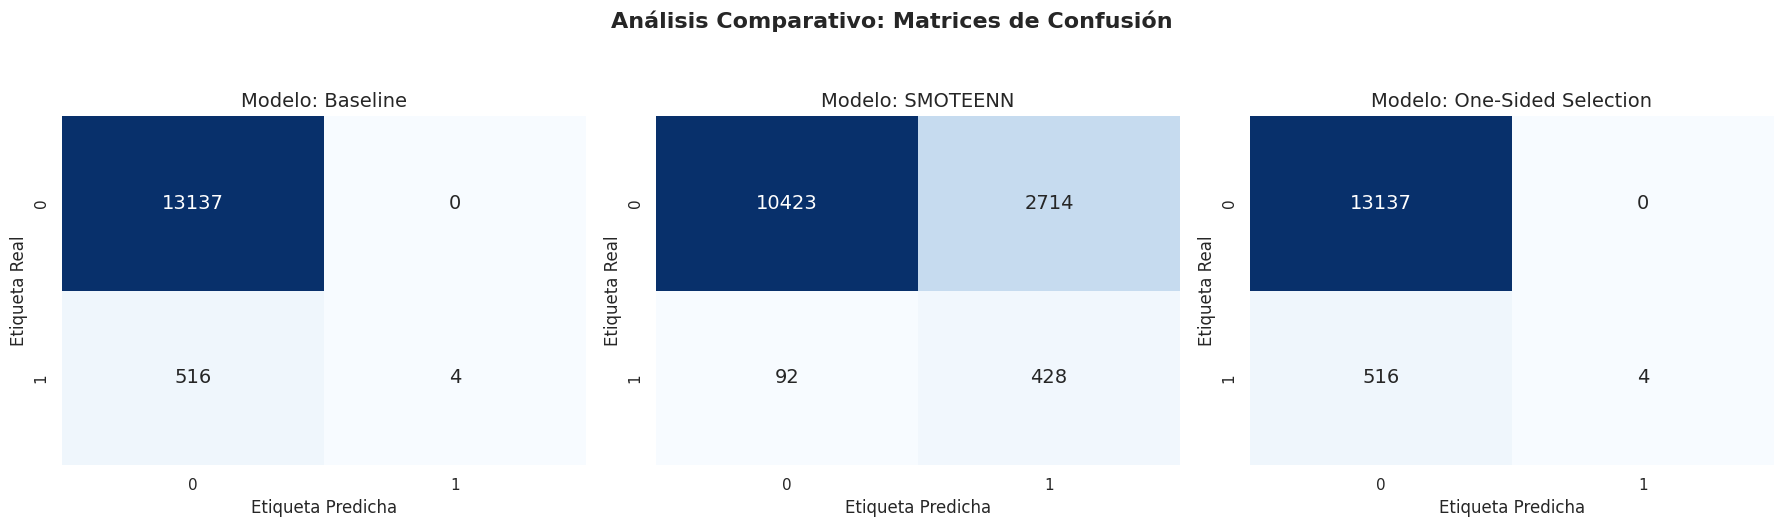

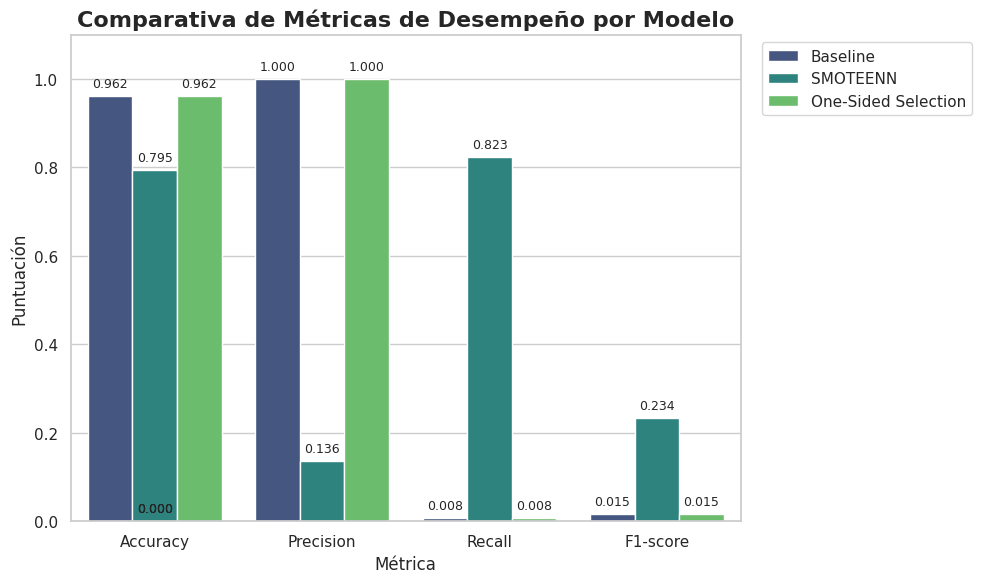

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Asegurar un estilo visual limpio y profesional para las gráficas
sns.set_theme(style="whitegrid")

# 5.1 Cálculo de Métricas y Generación de Tabla Comparativa
lista_metricas = []

for modelo, y_pred in resultados_predicciones.items():
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    lista_metricas.append({
        'Modelo': modelo,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

df_metricas = pd.DataFrame(lista_metricas)
print("TABLA COMPARATIVA DE MÉTRICAS:")
display(df_metricas.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-score'], color='lightgreen', axis=0))

# 5.2 Generación de Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Comparativo: Matrices de Confusión', fontsize=16, fontweight='bold', y=1.05)

for ax, (modelo, y_pred) in zip(axes, resultados_predicciones.items()):
    cm = confusion_matrix(y, y_pred)
    # cmap='Blues' ayuda a la preatención visual mencionada en teoría de gráficos
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 14})
    ax.set_title(f'Modelo: {modelo}', fontsize=14)
    ax.set_xlabel('Etiqueta Predicha', fontsize=12)
    ax.set_ylabel('Etiqueta Real', fontsize=12)

plt.tight_layout()
plt.show()

# 5.3 Gráfica Comparativa de Métricas
# Transformamos el DataFrame con melt() para facilitar la gráfica en Seaborn
df_melted = df_metricas.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación')

plt.figure(figsize=(10, 6))
grafico = sns.barplot(data=df_melted, x='Métrica', y='Puntuación', hue='Modelo', palette='viridis')
plt.title('Comparativa de Métricas de Desempeño por Modelo', fontsize=16, fontweight='bold')
plt.ylim(0, 1.1) # Rango probabilístico 0 - 1
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Anotación de los valores exactos sobre cada barra
for p in grafico.patches:
    grafico.annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontsize=9)
plt.tight_layout()
plt.show()

### 6. Análisis Comparativo, Discusión y Conclusiones

#### 6.1 Análisis Crítico: ¿Es el "Accuracy" suficiente para evaluar el problema?
Los resultados obtenidos demuestran empíricamente por qué la exactitud (*Accuracy*) **no es suficiente ni metodológicamente válida** para evaluar conjuntos de datos desbalanceados. Nos encontramos ante un claro ejemplo de la **Paradoja de la Exactitud**.

El modelo *Baseline* logró un impresionante $96.22\%$ de *Accuracy*. En un contexto inexperto, esto se consideraría un éxito rotundo. Sin embargo, al observar el *Recall* ($0.0076$), descubrimos que el modelo es estadísticamente ciego: prácticamente ignora a la clase minoritaria (Clase 1) y clasifica casi todas las instancias como Clase 0. El alto *Accuracy* es solo un espejismo estadístico producto del abrumador volumen de la clase mayoritaria. Para que un modelo predictivo sea útil en el mundo real (ej. detectar fraudes, fallas o enfermedades), debe ser evaluado a través de su capacidad para encontrar la clase de interés, haciendo del **Recall**, la **Precision** y el **F1-score** las métricas definitivas.

#### 6.2 Comparación de Resultados: Baseline vs. Modelos Balanceados
* **Baseline:** Presenta un sesgo total hacia la clase mayoritaria. Su *Precision* es perfecta ($1.0$) en la única o pocas veces que predijo la clase 1, pero su *Recall* cercano a cero indica que dejó pasar casi todos los verdaderos positivos (Falsos Negativos masivos). Su F1-score es ínfimo ($0.0152$).
* **One-Sided Selection (OSS):** Produjo **exactamente los mismos resultados** que el Baseline (Accuracy $0.9622$, Recall $0.0076$). Al usar la matriz de confusión, vemos que el algoritmo no alteró la frontera de decisión.
* **SMOTEENN:** Presentó un cambio drástico. El *Accuracy* cayó al $79.45\%$, pero **el Recall se disparó a $0.8230$**. Esto significa que el modelo ahora es capaz de identificar exitosamente a más del 82% de la clase minoritaria. Como efecto secundario del incremento de la sensibilidad, la *Precision* cayó a $0.1362$ (aumentaron los Falsos Positivos). Sin embargo, el **F1-score subió a $0.2337$**, demostrando una ganancia real de conocimiento sobre el fenómeno minoritario.

#### 6.3 Discusión y Conclusiones Finales

**A. El impacto del desbalance sobre el desempeño del modelo:**
El desbalance extremo obliga a los algoritmos como el SVM a optimizar su función de costo enfocándose en la clase que más ejemplos tiene. Geométricamente, el margen del hiperplano proyectado por el kernel RBF es "empujado" por la masa dominante de la Clase 0, colapsando el espacio de la Clase 1. Esto produce modelos inútiles en la práctica, que minimizan el error global a costa de anular la tasa de verdaderos positivos.

**B. Diferencias observadas entre SMOTEENN y One-Sided Selection:**
* **El fracaso de OSS en este escenario:** Como vimos en teoría, OSS es una técnica inteligente heurística que utiliza *Tomek Links* y la regla CNN para eliminar ejemplos de la clase mayoritaria, pero solo aquellos ruidosos o redundantes (*borderline*). Que OSS haya arrojado los mismos resultados que el Baseline indica que la Clase 0 es extremadamente densa y cohesiva. Al ser un submuestreo conservador, no eliminó suficientes ejemplos para contrarrestar el desbalance masivo; la presión geométrica sobre el SVM se mantuvo intacta.
* **El éxito de SMOTEENN:** Al ser un algoritmo híbrido, primero aplicó oversampling mediante interpolación (SMOTE), inflando artificialmente el espacio de la Clase 1. Posteriormente, la regla de Edición de Wilson (ENN) limpió las fronteras eliminando ejemplos cuyas clases diferían de sus vecinos. Esta combinación logró expandir la región de aceptación de la Clase 1 para el SVM, permitiendo que el hiperplano finalmente la capturara.

**C. ¿Qué método produjo los mejores resultados y por qué?**
**SMOTEENN produjo objetivamente los mejores resultados predictivos.** Aunque a simple vista el Accuracy bajó, el propósito del Machine Learning en clases desbalanceadas no es acertar lo obvio, sino encontrar las anomalías. SMOTEENN fue el único método capaz de "despertar" al modelo y hacerlo sensible a la Clase 1 (F1-score de $0.2337$ frente al $0.0152$ de los otros modelos). La elección de SMOTEENN se justifica técnica y matemáticamente por su capacidad para modificar la densidad topológica del espacio de características, combatiendo simultáneamente la falta de datos (oversampling) y la superposición de clases (undersampling de limpieza). En un contexto de negocios, es preferible tener falsos positivos que deban revisarse (lo que refleja su *Precision* baja) a tener un modelo que jamás detecte el evento crítico (lo que reflejaba el *Baseline*).